In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"

df = pd.read_csv(url, sep=";")

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)
display(df.head())
print("\nColumn names:")
print(df.columns.tolist())
print("\nQuality score distribution:")
print(df["quality"].value_counts().sort_index())




Dataset loaded successfully!
Dataset shape: (1599, 12)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5



Column names:
['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality']

Quality score distribution:
quality
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64


In [5]:
print("Dateset loaded successfully!")

Dateset loaded successfully!


In [6]:


# Step 3: Prepare the dataset

X = df.drop("quality", axis=1)
y = df["quality"]

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Scale features for machine learning
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data preparation completed!")
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)
print("\nTraining set prepared successfully.")



Data preparation completed!
Training data: (1279, 11)
Testing data: (320, 11)

Training set prepared successfully.


In [7]:


# Step 4: Train three machine learning models

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.svm import SVC

# Model 1: Random Forest
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
rf_model.fit(X_train, y_train)

# Model 2: SGD Classifier
sgd_model = SGDClassifier(
    max_iter=2000,
    random_state=42
)
sgd_model.fit(X_train_scaled, y_train)

# Model 3: Support Vector Classifier
svc_model = SVC()
svc_model.fit(X_train_scaled, y_train)

print("All 3 models trained successfully!")



All 3 models trained successfully!


In [8]:


from sklearn.metrics import accuracy_score

# Make predictions
rf_pred = rf_model.predict(X_test)
sgd_pred = sgd_model.predict(X_test_scaled)
svc_pred = svc_model.predict(X_test_scaled)

# Calculate accuracy
print("Random Forest Accuracy:",
      round(accuracy_score(y_test, rf_pred) * 100, 2), "%")

print("SGD Classifier Accuracy:",
      round(accuracy_score(y_test, sgd_pred) * 100, 2), "%")

print("SVC Accuracy:",
      round(accuracy_score(y_test, svc_pred) * 100, 2), "%")



Random Forest Accuracy: 67.81 %
SGD Classifier Accuracy: 51.25 %
SVC Accuracy: 62.5 %



Random Forest

Classification Report:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         2
           4       0.00      0.00      0.00        11
           5       0.71      0.76      0.73       136
           6       0.65      0.70      0.67       128
           7       0.71      0.55      0.62        40
           8       0.50      0.33      0.40         3

    accuracy                           0.68       320
   macro avg       0.43      0.39      0.40       320
weighted avg       0.65      0.68      0.66       320



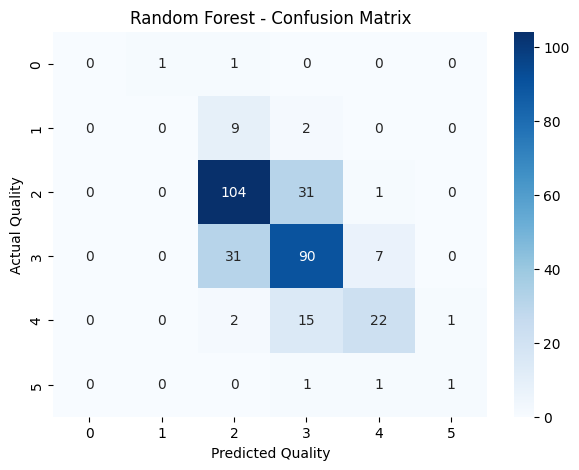


SGD Classifier

Classification Report:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         2
           4       0.00      0.00      0.00        11
           5       0.57      0.76      0.66       136
           6       0.51      0.28      0.36       128
           7       0.39      0.60      0.48        40
           8       0.00      0.00      0.00         3

    accuracy                           0.51       320
   macro avg       0.25      0.27      0.25       320
weighted avg       0.50      0.51      0.48       320



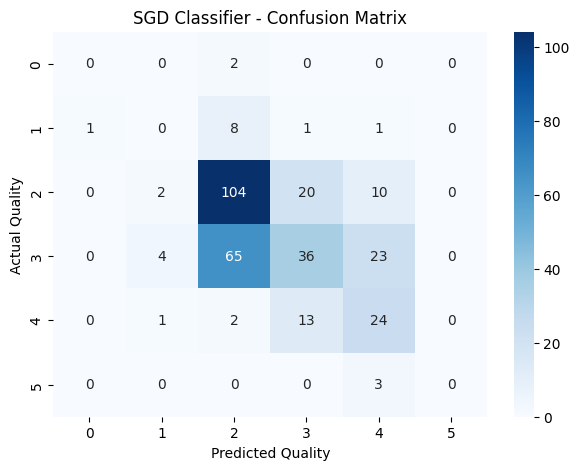


SVC

Classification Report:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         2
           4       0.00      0.00      0.00        11
           5       0.65      0.76      0.70       136
           6       0.58      0.65      0.61       128
           7       0.78      0.35      0.48        40
           8       0.00      0.00      0.00         3

    accuracy                           0.62       320
   macro avg       0.33      0.29      0.30       320
weighted avg       0.60      0.62      0.60       320



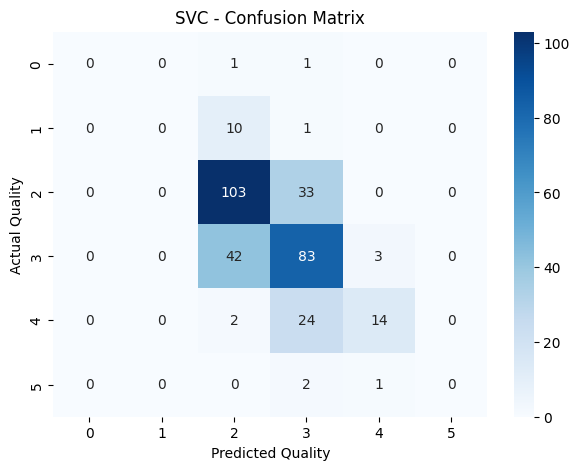

In [9]:


# Step 6: Evaluate all three models

from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

models = {
    "Random Forest": rf_pred,
    "SGD Classifier": sgd_pred,
    "SVC": svc_pred
}

for name, predictions in models.items():
    print("\n", "=" * 40)
    print(name)
    print("=" * 40)

    print("\nClassification Report:")
    print(classification_report(
        y_test,
        predictions,
        zero_division=0
    ))

    cm = confusion_matrix(y_test, predictions)

    plt.figure(figsize=(7, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(name + " - Confusion Matrix")
    plt.xlabel("Predicted Quality")
    plt.ylabel("Actual Quality")
    plt.show()



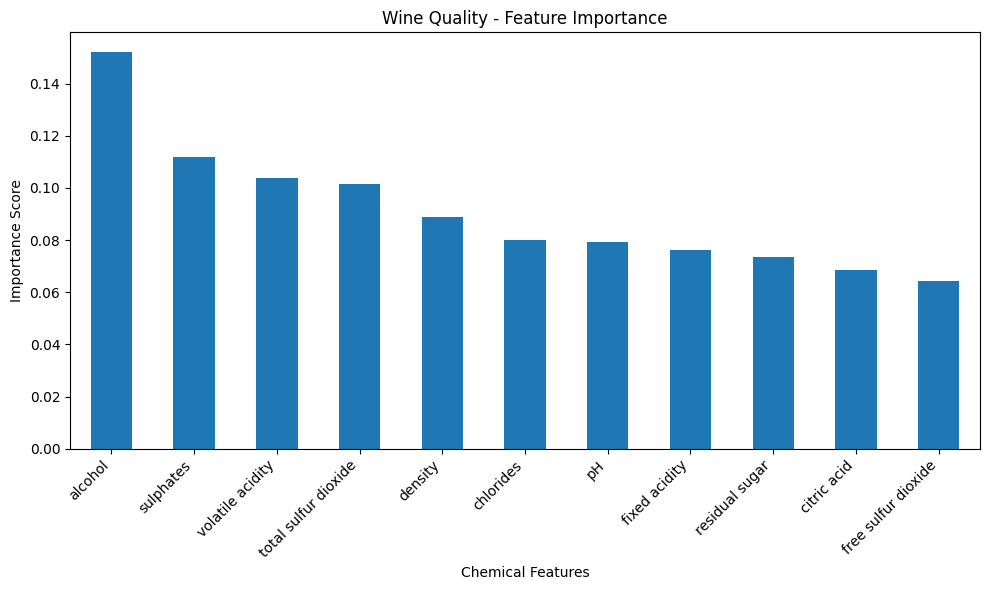

Feature importance analysis completed!


In [10]:


# Step 7: Random Forest Feature Importance

importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
importance.plot(kind="bar")
plt.title("Wine Quality - Feature Importance")
plt.xlabel("Chemical Features")
plt.ylabel("Importance Score")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

print("Feature importance analysis completed!")

In [12]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

results = []

predictions_dict = {
    "Random Forest": rf_pred,
    "SGD Classifier": sgd_pred,
    "SVC": svc_pred
}

for model_name, predictions in predictions_dict.items():
    results.append({
        "Model": model_name,
        "Accuracy": round(accuracy_score(y_test, predictions), 4),
        "Precision": round(precision_score(
            y_test, predictions,
            average="weighted", zero_division=0
        ), 4),
        "Recall": round(recall_score(
            y_test, predictions,
            average="weighted", zero_division=0
        ), 4),
        "F1 Score": round(f1_score(
            y_test, predictions,
            average="weighted", zero_division=0
        ), 4)
    })

results_df = pd.DataFrame(results)
display(results_df)

print("Model comparison completed!")




,Model,Accuracy,Precision,Recall,F1 Score
0,Random Forest,0.6781,0.6531,0.6781,0.6632
1,SGD Classifier,0.5125,0.4991,0.5125,0.4837
2,SVC,0.6250,0.6048,0.6250,0.6023


Model comparison completed!


In [13]:


# Step 9: Final Project Conclusion

best_model = results_df.loc[
    results_df["F1 Score"].idxmax()
]

print("WINE QUALITY PREDICTION - CONCLUSION")
print("-" * 40)

print("Best Model:", best_model["Model"])
print("Accuracy:", best_model["Accuracy"])
print("F1 Score:", best_model["F1 Score"])

print("\nConclusion:")
print(
    "Three machine learning models were trained to predict "
    "wine quality using physicochemical properties."
)
print(
    "The models were compared using accuracy, precision, recall, "
    "and F1 score. The model with the highest weighted F1 score "
    "performed best on the test dataset."
)
print(
    "Wine quality classes are imbalanced, so accuracy alone "
    "may not fully describe model performance."
)
print(
    "This project demonstrates how machine learning can help "
    "classify wine quality from chemical measurements."
)



WINE QUALITY PREDICTION - CONCLUSION
----------------------------------------
Best Model: Random Forest
Accuracy: 0.6781
F1 Score: 0.6632

Conclusion:
Three machine learning models were trained to predict wine quality using physicochemical properties.
The models were compared using accuracy, precision, recall, and F1 score. The model with the highest weighted F1 score performed best on the test dataset.
Wine quality classes are imbalanced, so accuracy alone may not fully describe model performance.
This project demonstrates how machine learning can help classify wine quality from chemical measurements.
